In [4]:
! pip install GitPython

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/3 [smmap]
   ------------- -------------------------- 1/3 [gitdb]
   ------------- -------------------------- 1/3 [gitdb]
   ------------- -------------------------- 1/3 [gitdb]
   ------------- -------------------------- 1/3 [gitdb]
   ------------- -------------------------- 1/3 [gitdb]
   ------------- -------------------------- 1/3 [gitdb]
   -------------------------- ------------- 2/3 [GitPython]
   -------------------------- ------------- 2/3 [GitPython]
   -------------------------- ------------- 2/3 [GitPython]
   -------------------------- ------------- 2/3 [GitPython]
   -------------------------- ------------- 2/3 [GitPython]
   -------------------------- ------------- 2/3 [GitPython]
   -------------------------- ------------- 2/3 [GitPython]
   -------------------------- ------------- 2/3 [GitPython]
   -------------------------- ------------- 2/3 [

In [15]:
from git import Repo
import json
import os

In [12]:
repo_url = "https://github.com/PhonePe/pulse.git"
destination = "D:\PHONEPAY\data"


Repo.clone_from(repo_url, destination)

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\lenovo\AppData\Local\Temp\ipykernel_17368\2164802029.py:2: SyntaxWarning: invalid escape sequence '\P'
  destination = "D:\PHONEPAY\data"


<git.repo.base.Repo 'D:\\PHONEPAY\\data\\.git'>

In [3]:
! pip install mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable
  Using cached mysql_connector_python-9.6.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
Using cached mysql_connector_python-9.6.0-cp313-cp313-win_amd64.whl (16.5 MB)


In [13]:
import mysql.connector
con_mysql = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234567890"
)
cursor_mysql = con_mysql.cursor()
print("MYSQL Connection Established")


MYSQL Connection Established


In [19]:
import os

path = "D:\PHONEPAY\data"

files = os.listdir(path)

print(files)

['.git', '.gitignore', 'data', 'LICENSE', 'README.md']


<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
C:\Users\lenovo\AppData\Local\Temp\ipykernel_17376\1280579902.py:3: SyntaxWarning: invalid escape sequence '\P'
  path = "D:\PHONEPAY\data"


In [20]:
for file in os.listdir(path):
    print(file)

.git
.gitignore
data
LICENSE
README.md


In [3]:
import json

In [21]:
for file in os.listdir(path):
    if file.endswith(".json"):
        print(file)

In [22]:
import json

for file in os.listdir(path):
    if file.endswith(".json"):
        file_path = os.path.join(path, file)

        with open(file_path, "r") as f:
            data = json.load(f)

        print(data)

In [25]:
import os
import json
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234567890",
    database="Phonepay_pulse"
)

cursor = conn.cursor()

path = r"D:\PHONEPAY\data\data\map\transaction\hover\country\india\state"

query = """
INSERT INTO map_transaction
(state, year, quarter, district, transaction_count, transaction_amount)
VALUES (%s, %s, %s, %s, %s, %s)
"""

inserted_rows = 0
batch_count = 0

for state in os.listdir(path):
    state_path = os.path.join(path, state)
    if not os.path.isdir(state_path):
        continue

    for year in os.listdir(state_path):
        year_path = os.path.join(state_path, year)
        if not os.path.isdir(year_path):
            continue

        for file in os.listdir(year_path):
            if not file.endswith(".json"):
                continue

            quarter = file.replace(".json", "")
            file_path = os.path.join(year_path, file)

            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            districts = data.get("data", {}).get("hoverDataList")

            if not districts:
                continue

            for item in districts:
                values = (
                    state.replace("-", " ").title(),
                    int(year),
                    int(quarter),
                    item.get("name"),
                    int(item.get("metric", [0])[0].get("count", 0)),
                    float(item.get("metric", [0])[0].get("amount", 0))
                )

                cursor.execute(query, values)
                inserted_rows += 1
                batch_count += 1

                if batch_count == 500:
                    conn.commit()
                    print("Committed:", inserted_rows)
                    batch_count = 0

conn.commit()
print("map_transaction inserted rows:", inserted_rows)

cursor.close()
conn.close()

Committed: 500
Committed: 1000
Committed: 1500
Committed: 2000
Committed: 2500
Committed: 3000
Committed: 3500
Committed: 4000
Committed: 4500
Committed: 5000
Committed: 5500
Committed: 6000
Committed: 6500
Committed: 7000
Committed: 7500
Committed: 8000
Committed: 8500
Committed: 9000
Committed: 9500
Committed: 10000
Committed: 10500
Committed: 11000
Committed: 11500
Committed: 12000
Committed: 12500
Committed: 13000
Committed: 13500
Committed: 14000
Committed: 14500
Committed: 15000
Committed: 15500
Committed: 16000
Committed: 16500
Committed: 17000
Committed: 17500
Committed: 18000
Committed: 18500
Committed: 19000
Committed: 19500
Committed: 20000
Committed: 20500
map_transaction inserted rows: 20604


In [27]:
print("Inserted rows:", inserted_rows)

Inserted rows: 20604


In [ ]:
print(os.listdir(path))

In [ ]:
print(data)

In [40]:
import os
import json
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234567890",
    database="Phonepay_pulse"
)

cursor = conn.cursor()

path = r"D:\PHONEPAY\data\data\top\transaction\country\india\state"

query = """
INSERT INTO top_transaction
(state, year, quarter, entity_type, entity_name, transaction_count, transaction_amount)
VALUES (%s, %s, %s, %s, %s, %s, %s)
"""

inserted_rows = 0
batch_count = 0

for state in os.listdir(path):
    state_path = os.path.join(path, state)
    if not os.path.isdir(state_path):
        continue

    for year in os.listdir(state_path):
        year_path = os.path.join(state_path, year)
        if not os.path.isdir(year_path):
            continue

        for file in os.listdir(year_path):
            if not file.endswith(".json"):
                continue

            quarter = file.replace(".json", "")
            file_path = os.path.join(year_path, file)

            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            top_data = data.get("data", {})

            if not top_data:
                continue

            for entity_type in ["states", "districts", "pincodes"]:
                entities = top_data.get(entity_type)

                if not entities:
                    continue

                for item in entities:
                    values = (
                        state.replace("-", " ").title(),
                        int(year),
                        int(quarter),
                        entity_type,
                        item.get("entityName"),
                        int(item.get("metric", {}).get("count", 0)),
                        float(item.get("metric", {}).get("amount", 0))
                    )

                    cursor.execute(query, values)
                    inserted_rows += 1
                    batch_count += 1

                    if batch_count == 500:
                        conn.commit()
                        print("Committed:", inserted_rows)
                        batch_count = 0

conn.commit()
print("top_transaction inserted rows:", inserted_rows)

cursor.close()
conn.close()

Committed: 500
Committed: 1000
Committed: 1500
Committed: 2000
Committed: 2500
Committed: 3000
Committed: 3500
Committed: 4000
Committed: 4500
Committed: 5000
Committed: 5500
Committed: 6000
Committed: 6500
Committed: 7000
Committed: 7500
Committed: 8000
Committed: 8500
Committed: 9000
Committed: 9500
Committed: 10000
Committed: 10500
Committed: 11000
Committed: 11500
Committed: 12000
Committed: 12500
Committed: 13000
Committed: 13500
Committed: 14000
Committed: 14500
Committed: 15000
Committed: 15500
Committed: 16000
Committed: 16500
Committed: 17000
Committed: 17500
Committed: 18000
top_transaction inserted rows: 18295


In [41]:
import os, json, mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234567890",
    database="Phonepay_pulse"
)
cursor = conn.cursor()

path = r"D:\PHONEPAY\data\data\aggregated\user\country\india\state"

query = """
INSERT INTO aggregated_user
(state, year, quarter, brand, transaction_count, percentage)
VALUES (%s, %s, %s, %s, %s, %s)
"""

count = 0

for state in os.listdir(path):
    sp = os.path.join(path, state)
    if not os.path.isdir(sp): continue

    for year in os.listdir(sp):
        yp = os.path.join(sp, year)
        if not os.path.isdir(yp): continue

        for file in os.listdir(yp):
            if not file.endswith(".json"): continue

            qp = file.replace(".json", "")
            fp = os.path.join(yp, file)

            with open(fp, "r") as f:
                data = json.load(f)

            users = data.get("data", {}).get("usersByDevice")
            if not users: continue

            for u in users:
                cursor.execute(query, (
                    state.replace("-", " ").title(),
                    int(year),
                    int(qp),
                    u.get("brand"),
                    int(u.get("count", 0)),
                    float(u.get("percentage", 0))
                ))
                count += 1

                if count % 500 == 0:
                    conn.commit()

conn.commit()
print("aggregated_user:", count)

cursor.close()
conn.close()

aggregated_user: 6732


In [42]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234567890",
    database="Phonepay_pulse"
)
cursor = conn.cursor()

path = r"D:\PHONEPAY\data\data\map\user\hover\country\india\state"

query = """
INSERT INTO map_user
(state, year, quarter, district, registered_users, app_opens)
VALUES (%s, %s, %s, %s, %s, %s)
"""

count = 0

for state in os.listdir(path):
    sp = os.path.join(path, state)
    if not os.path.isdir(sp): continue

    for year in os.listdir(sp):
        yp = os.path.join(sp, year)
        if not os.path.isdir(yp): continue

        for file in os.listdir(yp):
            if not file.endswith(".json"): continue

            qp = file.replace(".json", "")
            fp = os.path.join(yp, file)

            with open(fp, "r") as f:
                data = json.load(f)

            districts = data.get("data", {}).get("hoverData")
            if not districts: continue

            for district, val in districts.items():
                cursor.execute(query, (
                    state.replace("-", " ").title(),
                    int(year),
                    int(qp),
                    district,
                    int(val.get("registeredUsers", 0)),
                    int(val.get("appOpens", 0))
                ))
                count += 1

                if count % 500 == 0:
                    conn.commit()

conn.commit()
print("map_user:", count)

cursor.close()
conn.close()

map_user: 20608


In [43]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234567890",
    database="Phonepay_pulse"
)
cursor = conn.cursor()

path = r"D:\PHONEPAY\data\data\top\user\country\india\state"

query = """
INSERT INTO top_user
(state, year, quarter, entity_type, entity_name, registered_users)
VALUES (%s, %s, %s, %s, %s, %s)
"""

count = 0

for state in os.listdir(path):
    sp = os.path.join(path, state)
    if not os.path.isdir(sp): continue

    for year in os.listdir(sp):
        yp = os.path.join(sp, year)
        if not os.path.isdir(yp): continue

        for file in os.listdir(yp):
            if not file.endswith(".json"): continue

            qp = file.replace(".json", "")
            fp = os.path.join(yp, file)

            with open(fp, "r") as f:
                data = json.load(f)

            top = data.get("data", {})
            for typ in ["states", "districts", "pincodes"]:
                items = top.get(typ)
                if not items: continue

                for item in items:
                    cursor.execute(query, (
                        state.replace("-", " ").title(),
                        int(year),
                        int(qp),
                        typ,
                        item.get("name"),
                        int(item.get("registeredUsers", 0))
                    ))
                    count += 1

                    if count % 500 == 0:
                        conn.commit()

conn.commit()
print("top_user:", count)

cursor.close()
conn.close()

top_user: 18296


In [44]:
import os
import json
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234567890",
    database="Phonepay_pulse"
)

cursor = conn.cursor()

path = r"D:\PHONEPAY\data\data\aggregated\insurance\country\india\state"

query = """
INSERT INTO aggregated_insurance
(state, year, quarter, insurance_type, insurance_count, insurance_amount)
VALUES (%s, %s, %s, %s, %s, %s)
"""

inserted_rows = 0
batch_count = 0

for state in os.listdir(path):
    state_path = os.path.join(path, state)
    if not os.path.isdir(state_path):
        continue

    for year in os.listdir(state_path):
        year_path = os.path.join(state_path, year)
        if not os.path.isdir(year_path):
            continue

        for file in os.listdir(year_path):
            if not file.endswith(".json"):
                continue

            quarter = file.replace(".json", "")
            file_path = os.path.join(year_path, file)

            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            transactions = data.get("data", {}).get("transactionData")

            if not transactions:
                continue

            for item in transactions:
                values = (
                    state.replace("-", " ").title(),
                    int(year),
                    int(quarter),
                    item.get("name"),
                    int(item.get("paymentInstruments", [{}])[0].get("count", 0)),
                    float(item.get("paymentInstruments", [{}])[0].get("amount", 0))
                )

                cursor.execute(query, values)
                inserted_rows += 1
                batch_count += 1

                if batch_count == 500:
                    conn.commit()
                    print("Committed:", inserted_rows)
                    batch_count = 0

conn.commit()
print("aggregated_insurance inserted rows:", inserted_rows)

cursor.close()
conn.close()

Committed: 500
aggregated_insurance inserted rows: 682


In [45]:
import os
import json
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234567890",
    database="Phonepay_pulse"
)

cursor = conn.cursor()

path = r"D:\PHONEPAY\data\data\map\insurance\hover\country\india\state"

query = """
INSERT INTO map_insurance
(state, year, quarter, district, insurance_count, insurance_amount)
VALUES (%s, %s, %s, %s, %s, %s)
"""

inserted_rows = 0
batch_count = 0

for state in os.listdir(path):
    state_path = os.path.join(path, state)
    if not os.path.isdir(state_path):
        continue

    for year in os.listdir(state_path):
        year_path = os.path.join(state_path, year)
        if not os.path.isdir(year_path):
            continue

        for file in os.listdir(year_path):
            if not file.endswith(".json"):
                continue

            quarter = file.replace(".json", "")
            file_path = os.path.join(year_path, file)

            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            districts = data.get("data", {}).get("hoverDataList")

            if not districts:
                continue

            for item in districts:
                metric = item.get("metric", [{}])

                values = (
                    state.replace("-", " ").title(),
                    int(year),
                    int(quarter),
                    item.get("name"),
                    int(metric[0].get("count", 0)),
                    float(metric[0].get("amount", 0))
                )

                cursor.execute(query, values)
                inserted_rows += 1
                batch_count += 1

                if batch_count == 500:
                    conn.commit()
                    print("Committed:", inserted_rows)
                    batch_count = 0

conn.commit()
print("map_insurance inserted rows:", inserted_rows)

cursor.close()
conn.close()

Committed: 500
Committed: 1000
Committed: 1500
Committed: 2000
Committed: 2500
Committed: 3000
Committed: 3500
Committed: 4000
Committed: 4500
Committed: 5000
Committed: 5500
Committed: 6000
Committed: 6500
Committed: 7000
Committed: 7500
Committed: 8000
Committed: 8500
Committed: 9000
Committed: 9500
Committed: 10000
Committed: 10500
Committed: 11000
Committed: 11500
Committed: 12000
Committed: 12500
Committed: 13000
Committed: 13500
map_insurance inserted rows: 13876


In [46]:
import os
import json
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234567890",
    database="Phonepay_pulse"
)

cursor = conn.cursor()

path = r"D:\PHONEPAY\data\data\top\insurance\country\india\state"

query = """
INSERT INTO top_insurance
(state, year, quarter, entity_type, entity_name, insurance_count, insurance_amount)
VALUES (%s, %s, %s, %s, %s, %s, %s)
"""

inserted_rows = 0
batch_count = 0

for state in os.listdir(path):
    state_path = os.path.join(path, state)
    if not os.path.isdir(state_path):
        continue

    for year in os.listdir(state_path):
        year_path = os.path.join(state_path, year)
        if not os.path.isdir(year_path):
            continue

        for file in os.listdir(year_path):
            if not file.endswith(".json"):
                continue

            quarter = file.replace(".json", "")
            file_path = os.path.join(year_path, file)

            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            top_data = data.get("data", {})

            if not top_data:
                continue

            for entity_type in ["states", "districts", "pincodes"]:
                entities = top_data.get(entity_type)

                if not entities:
                    continue

                for item in entities:
                    metric = item.get("metric", {})

                    values = (
                        state.replace("-", " ").title(),
                        int(year),
                        int(quarter),
                        entity_type,
                        item.get("entityName"),
                        int(metric.get("count", 0)),
                        float(metric.get("amount", 0))
                    )

                    cursor.execute(query, values)
                    inserted_rows += 1
                    batch_count += 1

                    if batch_count == 500:
                        conn.commit()
                        print("Committed:", inserted_rows)
                        batch_count = 0

conn.commit()
print("top_insurance inserted rows:", inserted_rows)

cursor.close()
conn.close()

Committed: 500
Committed: 1000
Committed: 1500
Committed: 2000
Committed: 2500
Committed: 3000
Committed: 3500
Committed: 4000
Committed: 4500
Committed: 5000
Committed: 5500
Committed: 6000
Committed: 6500
Committed: 7000
Committed: 7500
Committed: 8000
Committed: 8500
Committed: 9000
Committed: 9500
Committed: 10000
Committed: 10500
Committed: 11000
Committed: 11500
Committed: 12000
top_insurance inserted rows: 12276


In [1]:
! pip install pandas matplotlib seaborn mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234567890",
    database="Phonepay_pulse"
)

In [5]:
query = "SELECT * FROM aggregated_transaction"

df = pd.read_sql(query, conn)

print(df.head())
print(df.shape)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7036\3710494121.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


   id                      state  year  quarter          transaction_type  \
0   1  Andaman & Nicobar Islands  2018        1  Recharge & bill payments   
1   2  Andaman & Nicobar Islands  2018        1     Peer-to-peer payments   
2   3  Andaman & Nicobar Islands  2018        1         Merchant payments   
3   4  Andaman & Nicobar Islands  2018        1        Financial Services   
4   5  Andaman & Nicobar Islands  2018        1                    Others   

   transaction_count  transaction_amount  
0               4200        1.845307e+06  
1               1871        1.213866e+07  
2                298        4.525072e+05  
3                 33        1.060142e+04  
4                256        1.846899e+05  
(20136, 7)


In [6]:
top_states = df.groupby("state")["transaction_amount"].sum().sort_values(ascending=False).head(10)

print(top_states)

state
Telangana         1.666238e+14
Karnataka         1.627149e+14
Maharashtra       1.614968e+14
Andhra Pradesh    1.386763e+14
Uttar Pradesh     1.075408e+14
Rajasthan         1.053729e+14
Madhya Pradesh    7.650112e+13
Bihar             7.160540e+13
West Bengal       6.233666e+13
Odisha            4.905593e+13
Name: transaction_amount, dtype: float64


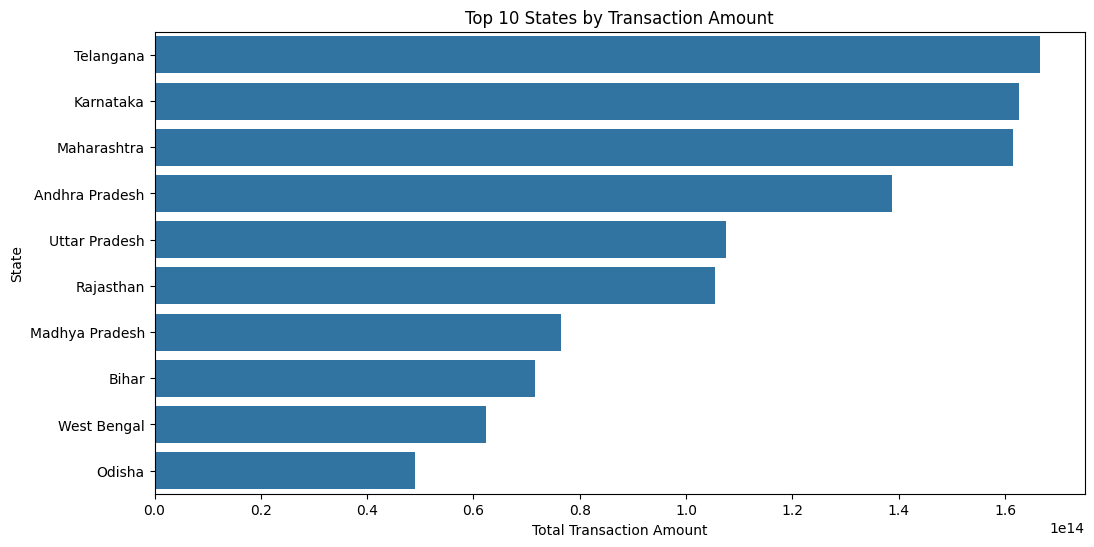

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=top_states.values, y=top_states.index)

plt.title("Top 10 States by Transaction Amount")
plt.xlabel("Total Transaction Amount")
plt.ylabel("State")
plt.show()

In [8]:
top_categories = df.groupby("transaction_type")["transaction_amount"].sum().sort_values(ascending=False)

print(top_categories)

transaction_type
Peer-to-peer payments       1.066109e+15
Merchant payments           2.613595e+14
Recharge & bill payments    5.335504e+13
Others                      6.971226e+11
Financial Services          5.680751e+11
Name: transaction_amount, dtype: float64


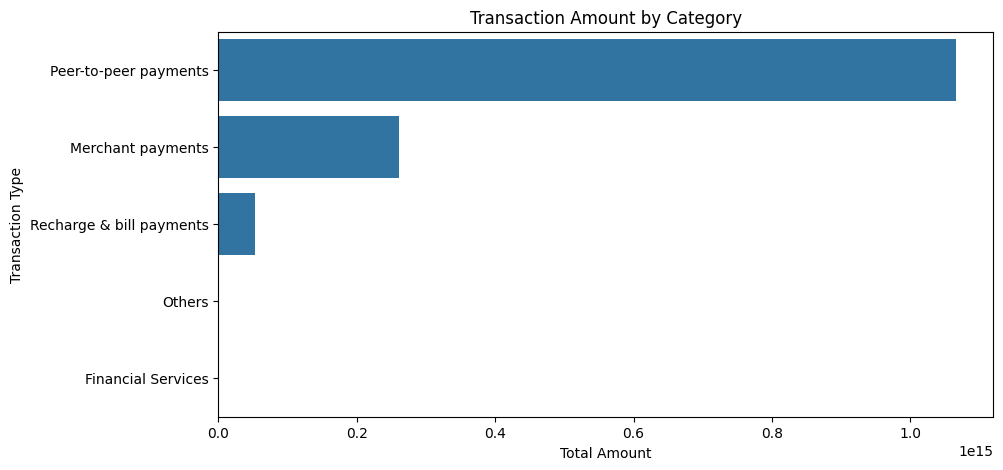

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(x=top_categories.values, y=top_categories.index)

plt.title("Transaction Amount by Category")
plt.xlabel("Total Amount")
plt.ylabel("Transaction Type")
plt.show()

In [10]:
year_trend = df.groupby("year")["transaction_amount"].sum()

print(year_trend)

year
2018    6.492182e+12
2019    2.510675e+13
2020    5.856465e+13
2021    1.383948e+14
2022    2.570653e+14
2023    3.779673e+14
2024    5.184982e+14
Name: transaction_amount, dtype: float64


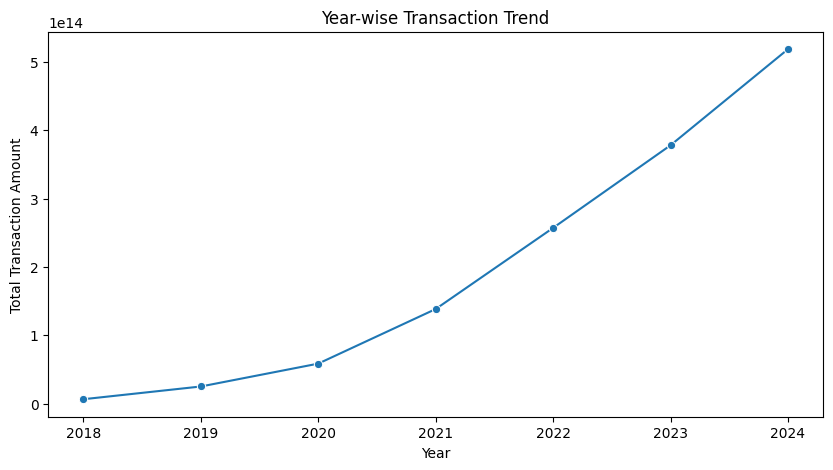

In [11]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=year_trend.index, y=year_trend.values, marker="o")

plt.title("Year-wise Transaction Trend")
plt.xlabel("Year")
plt.ylabel("Total Transaction Amount")
plt.show()

In [12]:
quarter_trend = df.groupby(["year", "quarter"])["transaction_amount"].sum().reset_index()

print(quarter_trend.head())

   year  quarter  transaction_amount
0  2018        1        6.873337e+11
1  2018        2        1.217497e+12
2  2018        3        1.900406e+12
3  2018        4        2.686945e+12
4  2019        1        3.960085e+12


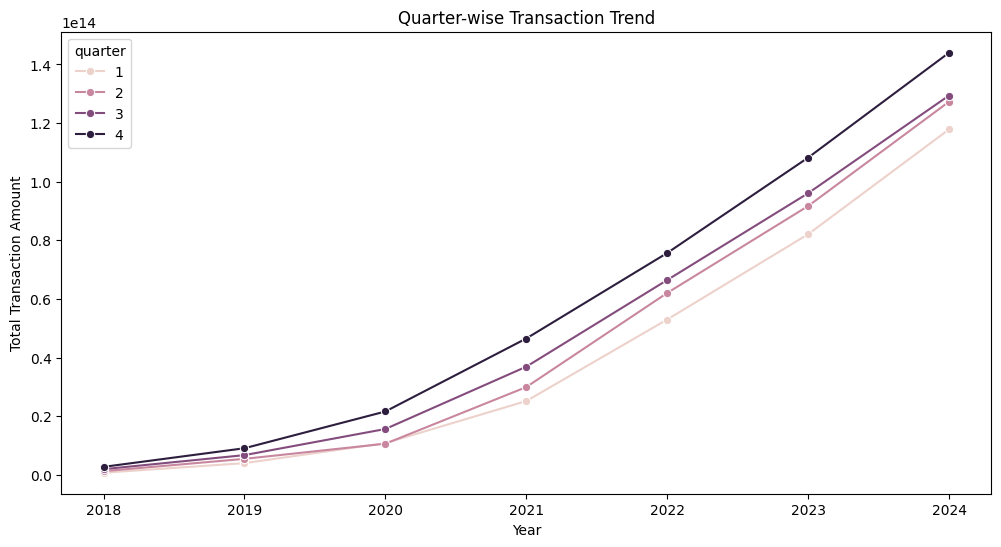

In [13]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=quarter_trend, x="year", y="transaction_amount", hue="quarter", marker="o")

plt.title("Quarter-wise Transaction Trend")
plt.xlabel("Year")
plt.ylabel("Total Transaction Amount")
plt.show()

In [14]:
state_share = df.groupby("state")["transaction_amount"].sum()
state_share = (state_share / state_share.sum()) * 100

top5 = state_share.sort_values(ascending=False).head(5)

print(top5)

state
Telangana         12.055939
Karnataka         11.773111
Maharashtra       11.684976
Andhra Pradesh    10.033819
Uttar Pradesh      7.781035
Name: transaction_amount, dtype: float64


In [15]:
cat_share = df.groupby("transaction_type")["transaction_amount"].sum()
cat_share = (cat_share / cat_share.sum()) * 100

print(cat_share)

transaction_type
Financial Services           0.041103
Merchant payments           18.910466
Others                       0.050440
Peer-to-peer payments       77.137529
Recharge & bill payments     3.860463
Name: transaction_amount, dtype: float64


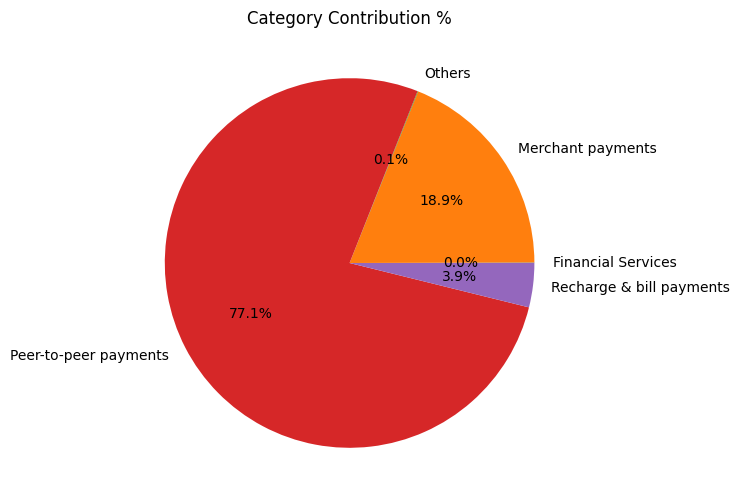

In [16]:
cat_share.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Category Contribution %")
plt.show()

In [17]:
year_data = df.groupby("year")["transaction_amount"].sum()

growth = year_data.pct_change() * 100

print(growth)

year
2018           NaN
2019    286.722894
2020    133.262537
2021    136.311160
2022     85.747827
2023     47.031594
2024     37.180724
Name: transaction_amount, dtype: float64


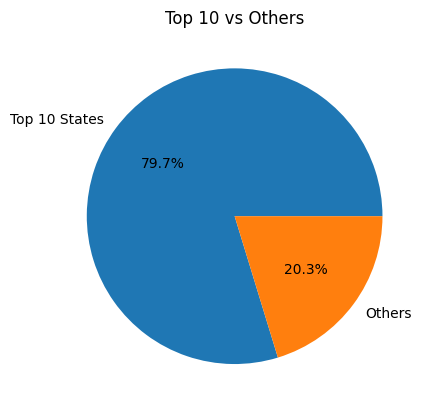

In [18]:
top10 = df.groupby("state")["transaction_amount"].sum().sort_values(ascending=False)

top10_sum = top10.head(10).sum()
others_sum = top10.sum() - top10_sum

labels = ["Top 10 States", "Others"]
values = [top10_sum, others_sum]

plt.pie(values, labels=labels, autopct="%1.1f%%")
plt.title("Top 10 vs Others")
plt.show()

In [19]:
df_map = pd.read_sql("SELECT * FROM map_transaction", conn)

top_districts = df_map.groupby("district")["transaction_amount"].sum().sort_values(ascending=False).head(10)

print(top_districts)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7036\1699003166.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_map = pd.read_sql("SELECT * FROM map_transaction", conn)


district
bengaluru urban district       1.993784e+13
hyderabad district             1.190694e+13
pune district                  9.730218e+12
jaipur district                7.854092e+12
rangareddy district            7.155140e+12
medchal malkajgiri district    5.758878e+12
visakhapatnam district         4.198568e+12
guntur district                3.174527e+12
krishna district               3.142856e+12
patna district                 3.110762e+12
Name: transaction_amount, dtype: float64


In [20]:
df["avg_value"] = df["transaction_amount"] / df["transaction_count"]

avg_state = df.groupby("state")["avg_value"].mean().sort_values(ascending=False).head(10)

print(avg_state)

state
Ladakh                       2140.959620
Andaman & Nicobar Islands    2061.531190
Lakshadweep                  1925.832656
Mizoram                      1835.084487
Arunachal Pradesh            1719.441090
Nagaland                     1695.492297
Manipur                      1619.937350
Meghalaya                    1515.808157
Sikkim                       1508.602222
Punjab                       1412.341544
Name: avg_value, dtype: float64


In [21]:
df_user = pd.read_sql("SELECT * FROM aggregated_user", conn)

brand_users = df_user.groupby("brand")["transaction_count"].sum().sort_values(ascending=False)

print(brand_users)

brand
Xiaomi        869562617
Samsung       671603711
Vivo          625415019
Oppo          420250245
Others        282950234
Realme        219973222
Apple          95947314
Motorola       73340734
OnePlus        63677211
Huawei         57129693
Lenovo         42564548
Tecno          12388623
Micromax       11132859
Infinix         5142870
Asus            4295498
Gionee          3082772
Lava            1530109
HMD Global       336632
Lyf                1271
COOLPAD              10
Name: transaction_count, dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_7036\1724761501.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_user = pd.read_sql("SELECT * FROM aggregated_user", conn)


In [22]:
df_user_map = pd.read_sql("SELECT * FROM map_user", conn)

df_user_map["engagement"] = df_user_map["app_opens"] / df_user_map["registered_users"]

engagement = df_user_map.groupby("district")["engagement"].mean().sort_values(ascending=False).head(10)

print(engagement)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7036\3710642135.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_user_map = pd.read_sql("SELECT * FROM map_user", conn)


district
noklak district                      1582.507171
eastern west khasi hills district    1510.289986
south west khasi hills district      1060.922184
senapati district                     949.231964
kekri district                        791.861733
pakke kessang district                706.246399
dangs district                        591.370177
kamle district                        582.668765
shi yomi district                     558.168934
muzaffarabad district                 550.901877
Name: engagement, dtype: float64


In [23]:
df_ins = pd.read_sql("SELECT * FROM aggregated_insurance", conn)

ins_trend = df_ins.groupby("year")["insurance_amount"].sum()

print(ins_trend)

year
2020    2.942072e+08
2021    1.499170e+09
2022    4.238843e+09
2023    6.056606e+09
2024    7.926752e+09
Name: insurance_amount, dtype: float64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_7036\1681125538.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ins = pd.read_sql("SELECT * FROM aggregated_insurance", conn)


In [24]:
df_top = pd.read_sql("SELECT * FROM top_transaction", conn)

top_entities = df_top.groupby("entity_name")["transaction_amount"].sum().sort_values(ascending=False).head(10)

print(top_entities)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7036\474433092.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top = pd.read_sql("SELECT * FROM top_transaction", conn)


entity_name
bengaluru urban       1.993784e+13
hyderabad             1.190694e+13
pune                  9.730218e+12
jaipur                7.854092e+12
rangareddy            7.155140e+12
medchal malkajgiri    5.758878e+12
visakhapatnam         4.198568e+12
guntur                3.174527e+12
patna                 3.110762e+12
khordha               2.992147e+12
Name: transaction_amount, dtype: float64


In [25]:
season = df.groupby("quarter")["transaction_amount"].sum()

print(season)

quarter
1    2.934209e+14
2    3.280969e+14
3    3.529326e+14
4    4.076388e+14
Name: transaction_amount, dtype: float64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_7036\2583522580.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT state, SUM(transaction_amount) AS total_spending FROM aggregated_transaction GROUP BY state", conn)


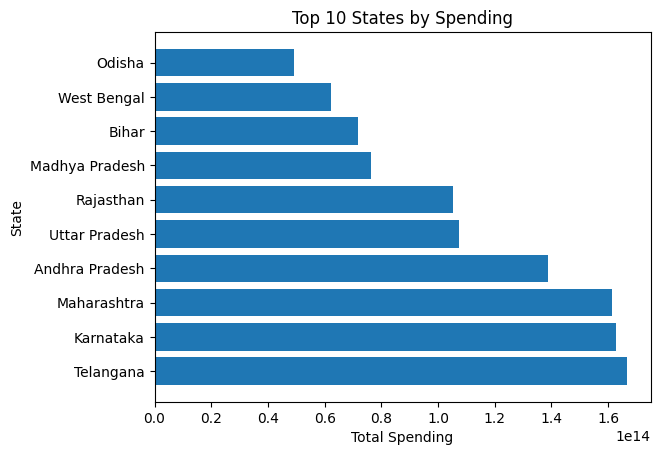

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#1. Customer Segmentation (Top States)

df = pd.read_sql("SELECT state, SUM(transaction_amount) AS total_spending FROM aggregated_transaction GROUP BY state", conn)

top_states = df.sort_values(by="total_spending", ascending=False).head(10)

plt.figure()
plt.barh(top_states["state"], top_states["total_spending"])
plt.title("Top 10 States by Spending")
plt.xlabel("Total Spending")
plt.ylabel("State")
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7036\2906516864.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT transaction_type, SUM(transaction_amount) AS total_amount FROM aggregated_transaction GROUP BY transaction_type", conn)


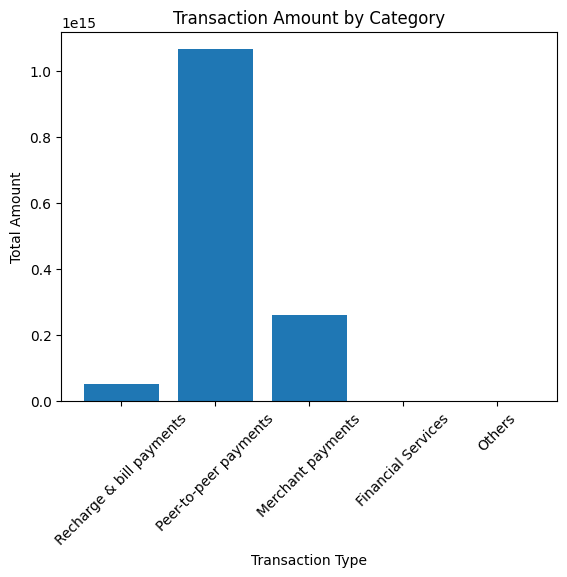

In [ ]:
#2. Payment Performance (Transaction Categories)

df = pd.read_sql("SELECT transaction_type, SUM(transaction_amount) AS total_amount FROM aggregated_transaction GROUP BY transaction_type", conn)

plt.figure()
plt.bar(df["transaction_type"], df["total_amount"])
plt.title("Transaction Amount by Category")
plt.xlabel("Transaction Type")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7036\1629851258.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT district, SUM(transaction_amount) AS total_amount FROM map_transaction GROUP BY district", conn)


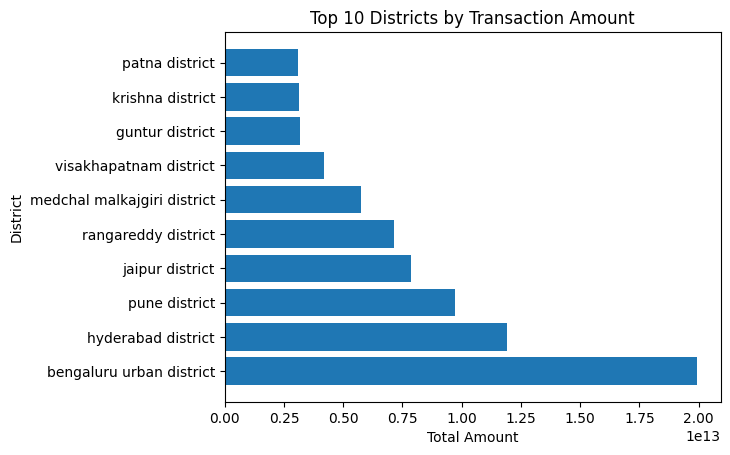

In [ ]:
#3. Geographical Insights (Top Districts)

df = pd.read_sql("SELECT district, SUM(transaction_amount) AS total_amount FROM map_transaction GROUP BY district", conn)

top_districts = df.sort_values(by="total_amount", ascending=False).head(10)

plt.figure()
plt.barh(top_districts["district"], top_districts["total_amount"])
plt.title("Top 10 Districts by Transaction Amount")
plt.xlabel("Total Amount")
plt.ylabel("District")
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7036\303889347.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT district, SUM(app_opens) AS total_app_opens FROM map_user GROUP BY district", conn)


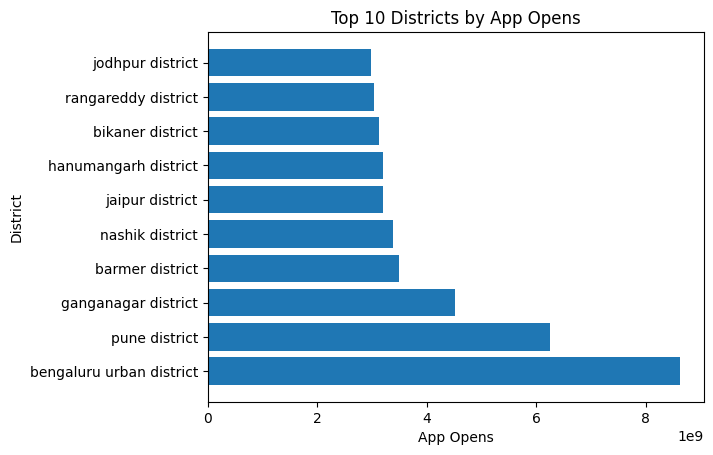

In [ ]:
#4. User Engagement (App Opens)

df = pd.read_sql("SELECT district, SUM(app_opens) AS total_app_opens FROM map_user GROUP BY district", conn)

top_engagement = df.sort_values(by="total_app_opens", ascending=False).head(10)

plt.figure()
plt.barh(top_engagement["district"], top_engagement["total_app_opens"])
plt.title("Top 10 Districts by App Opens")
plt.xlabel("App Opens")
plt.ylabel("District")
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7036\209421773.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT state, SUM(insurance_amount) AS total_insurance FROM aggregated_insurance GROUP BY state", conn)


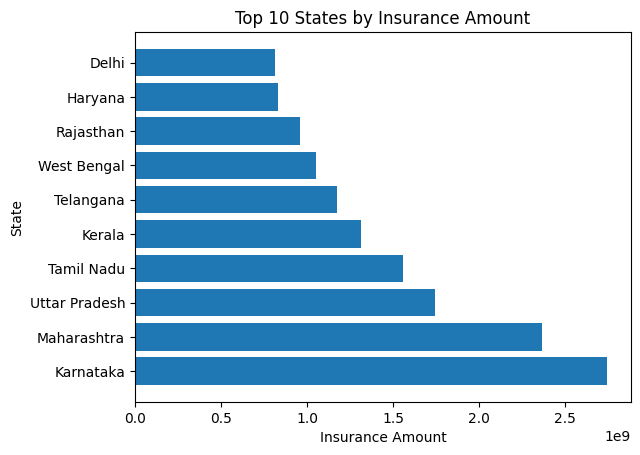

In [32]:
#5. Insurance Insights (Top States)

df = pd.read_sql("SELECT state, SUM(insurance_amount) AS total_insurance FROM aggregated_insurance GROUP BY state", conn)

top_insurance = df.sort_values(by="total_insurance", ascending=False).head(10)

plt.figure()
plt.barh(top_insurance["state"], top_insurance["total_insurance"])
plt.title("Top 10 States by Insurance Amount")
plt.xlabel("Insurance Amount")
plt.ylabel("State")
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7036\1193760417.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT year, SUM(transaction_amount) AS total_amount FROM aggregated_transaction GROUP BY year", conn)


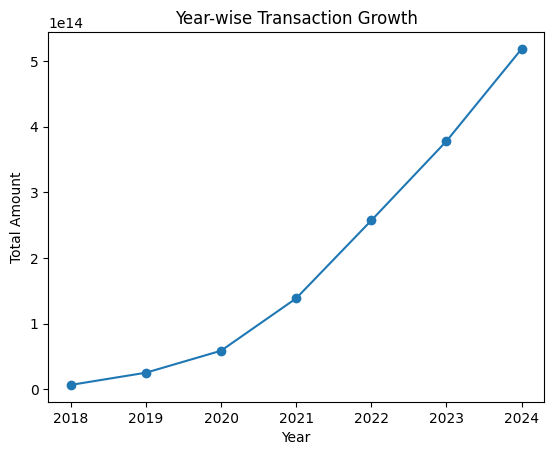

In [33]:
#6.Year-wise Growth Chart 

df = pd.read_sql("SELECT year, SUM(transaction_amount) AS total_amount FROM aggregated_transaction GROUP BY year", conn)

plt.figure()
plt.plot(df["year"], df["total_amount"], marker="o")
plt.title("Year-wise Transaction Growth")
plt.xlabel("Year")
plt.ylabel("Total Amount")
plt.show()

In [34]:
! pip install streamlit pandas mysql-connector-python plotly

Defaulting to user installation because normal site-packages is not writeable
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.1 MB 5.0 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.1 MB 5.6 MB/s eta 0:00:02
   --------------- ------------------------ 3.4/9.1 MB 5.1 MB/s eta 0:00:02
   ----------------- ---------------------- 3.9/9.1 MB 4.4 MB/s eta 0:00:02
   ------------------- -------------------- 4.5/9.1 MB 4.4 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.1 MB 4.1 MB/s eta 0:00:02
   ---------------------- ----------------- 5.0/9.1 MB 3.5 MB/s eta 0:00:02
   ---------------------- ----------------- 5.0/9

In [35]:
import streamlit as st
import pandas as pd
import mysql.connector
import plotly.express as px

st.set_page_config(page_title="PhonePe Dashboard", layout="wide")

st.title("📊 PhonePe Transaction Insights Dashboard")

# MySQL connection
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234567890",
    database="Phonepay_pulse"
)

# Load data
@st.cache_data
def load_data():
    query = "SELECT * FROM aggregated_transaction"
    df = pd.read_sql(query, conn)
    return df

df = load_data()

st.sidebar.header("Filters")

year_list = sorted(df["year"].unique())
selected_year = st.sidebar.selectbox("Select Year", year_list)

state_list = sorted(df["state"].unique())
selected_state = st.sidebar.selectbox("Select State", state_list)

filtered_df = df[(df["year"] == selected_year) & (df["state"] == selected_state)]

# KPIs
total_amount = filtered_df["transaction_amount"].sum()
total_count = filtered_df["transaction_count"].sum()
avg_transaction = total_amount / total_count if total_count != 0 else 0

col1, col2, col3 = st.columns(3)

col1.metric("Total Transaction Amount", round(total_amount, 2))
col2.metric("Total Transaction Count", int(total_count))
col3.metric("Average Transaction Value", round(avg_transaction, 2))

st.divider()

# Chart 1: Transaction category
st.subheader("Transaction Amount by Category")

category_df = filtered_df.groupby("transaction_type")["transaction_amount"].sum().reset_index()

fig1 = px.bar(
    category_df,
    x="transaction_type",
    y="transaction_amount",
    title="Category-wise Transaction Amount"
)

st.plotly_chart(fig1, use_container_width=True)

# Chart 2: Year-wise trend
st.subheader("Year-wise Transaction Trend")

year_df = df.groupby("year")["transaction_amount"].sum().reset_index()

fig2 = px.line(
    year_df,
    x="year",
    y="transaction_amount",
    markers=True,
    title="Year-wise Transaction Amount"
)

st.plotly_chart(fig2, use_container_width=True)

# Chart 3: Top 10 states
st.subheader("Top 10 States by Transaction Amount")

top_states = df.groupby("state")["transaction_amount"].sum().reset_index()
top_states = top_states.sort_values(by="transaction_amount", ascending=False).head(10)

fig3 = px.bar(
    top_states,
    x="transaction_amount",
    y="state",
    orientation="h",
    title="Top 10 States"
)

st.plotly_chart(fig3, use_container_width=True)

# Show data
st.subheader("Filtered Data")
st.dataframe(filtered_df)

2026-04-24 16:31:33.364 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 16:31:33.367 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 16:31:34.168 
  command:

    streamlit run C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-24 16:31:34.169 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 16:31:34.170 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 16:31:34.287 No runtime found, using MemoryCacheStorageManager
2026-04-24 16:31:34.288 No runtime found, using MemoryCacheStor

DeltaGenerator()

In [36]:
! pip install streamlit

Defaulting to user installation because normal site-packages is not writeable


In [37]:
! pip install plotly

Defaulting to user installation because normal site-packages is not writeable


In [9]:
! pip install nbformat

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [fastjsonschema]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   ---------------------------------------- 2/2 [nbformat]



In [3]:
! pip install ipython

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import pandas as pd
import plotly.express as px
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234567890",
    database="Phonepay_pulse"
)

df = pd.read_sql("SELECT * FROM aggregated_transaction", conn)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_21024\3913138276.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM aggregated_transaction", conn)


In [3]:
map_df = df.groupby("state")["transaction_amount"].sum().reset_index()

In [4]:
state_coords = {
    "Andhra Pradesh": [15.9129, 79.7400],
    "Tamil Nadu": [11.1271, 78.6569],
    "Karnataka": [15.3173, 75.7139],
    "Maharashtra": [19.7515, 75.7139],
    "West Bengal": [22.9868, 87.8550],
    "Delhi": [28.7041, 77.1025],
    "Uttar Pradesh": [26.8467, 80.9462],
    "Kerala": [10.8505, 76.2711],
    "Gujarat": [22.2587, 71.1924],
    "Rajasthan": [27.0238, 74.2179]
}

In [5]:
map_df["lat"] = map_df["state"].map(lambda x: state_coords.get(x, [None, None])[0])
map_df["lon"] = map_df["state"].map(lambda x: state_coords.get(x, [None, None])[1])

map_df = map_df.dropna()

In [6]:
fig = px.scatter_geo(
    map_df,
    lat="lat",
    lon="lon",
    size="transaction_amount",
    hover_name="state",
    hover_data=["transaction_amount"],
    title="India State-wise Transaction Map",
    scope="asia"
)

fig.update_geos(
    center={"lat": 22.9734, "lon": 78.6569},
    projection_scale=5
)

fig.show()

NameError: name 'map_df' is not defined

In [7]:
import pandas as pd
import plotly.express as px
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234567890",
    database="Phonepay_pulse"
)

df = pd.read_sql("SELECT * FROM aggregated_transaction", conn)

map_df = df.groupby("state")["transaction_amount"].sum().reset_index()

state_coords = {
    "Tamil Nadu": [11.1271, 78.6569],
    "Karnataka": [15.3173, 75.7139],
    "Maharashtra": [19.7515, 75.7139],
    "Delhi": [28.7041, 77.1025],
    "West Bengal": [22.9868, 87.8550],
    "Kerala": [10.8505, 76.2711]
}

map_df["lat"] = map_df["state"].map(lambda x: state_coords.get(x, [None, None])[0])
map_df["lon"] = map_df["state"].map(lambda x: state_coords.get(x, [None, None])[1])

map_df = map_df.dropna()

fig = px.scatter_geo(
    map_df,
    lat="lat",
    lon="lon",
    size="transaction_amount",
    hover_name="state",
    title="India Transaction Map",
    scope="asia"
)

fig.update_geos(center={"lat": 22.9734, "lon": 78.6569}, projection_scale=5)

fig.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_17376\3841028858.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM aggregated_transaction", conn)


In [9]:
import pandas as pd
import plotly.express as px
import mysql.connector

# MySQL connection
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234567890",
    database="Phonepay_pulse"
)

# Load transaction data
df = pd.read_sql("SELECT * FROM aggregated_transaction", conn)

# State-wise total transaction amount
map_df = df.groupby("state")["transaction_amount"].sum().reset_index()

# State latitude and longitude
state_coords = {
    "Andaman & Nicobar Islands": [11.7401, 92.6586],
    "Andhra Pradesh": [15.9129, 79.7400],
    "Arunachal Pradesh": [28.2180, 94.7278],
    "Assam": [26.2006, 92.9376],
    "Bihar": [25.0961, 85.3131],
    "Chandigarh": [30.7333, 76.7794],
    "Chhattisgarh": [21.2787, 81.8661],
    "Delhi": [28.7041, 77.1025],
    "Goa": [15.2993, 74.1240],
    "Gujarat": [22.2587, 71.1924],
    "Haryana": [29.0588, 76.0856],
    "Himachal Pradesh": [31.1048, 77.1734],
    "Jammu & Kashmir": [33.7782, 76.5762],
    "Jharkhand": [23.6102, 85.2799],
    "Karnataka": [15.3173, 75.7139],
    "Kerala": [10.8505, 76.2711],
    "Ladakh": [34.1526, 77.5770],
    "Madhya Pradesh": [22.9734, 78.6569],
    "Maharashtra": [19.7515, 75.7139],
    "Manipur": [24.6637, 93.9063],
    "Meghalaya": [25.4670, 91.3662],
    "Mizoram": [23.1645, 92.9376],
    "Nagaland": [26.1584, 94.5624],
    "Odisha": [20.9517, 85.0985],
    "Punjab": [31.1471, 75.3412],
    "Rajasthan": [27.0238, 74.2179],
    "Sikkim": [27.5330, 88.5122],
    "Tamil Nadu": [11.1271, 78.6569],
    "Telangana": [18.1124, 79.0193],
    "Tripura": [23.9408, 91.9882],
    "Uttar Pradesh": [26.8467, 80.9462],
    "Uttarakhand": [30.0668, 79.0193],
    "West Bengal": [22.9868, 87.8550]
}

# Add latitude and longitude
map_df["lat"] = map_df["state"].map(lambda x: state_coords.get(x, [None, None])[0])
map_df["lon"] = map_df["state"].map(lambda x: state_coords.get(x, [None, None])[1])

map_df = map_df.dropna()

df = px.data.election()
geojson = px.data.election_geojson()

fig = px.choropleth_map(df, geojson=geojson, color="Bergeron",
                           locations="district", featureidkey="properties.district",
                           center={"lat": 45.5517, "lon": -73.7073},
                           map_style="carto-positron", zoom=9)
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

fig.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_17376\3301221850.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM aggregated_transaction", conn)


In [10]:
! pip install requests

Defaulting to user installation because normal site-packages is not writeable


In [11]:
! pip install plotly requests streamlit pandas mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable


In [12]:
import requests
import plotly.graph_objects as go